[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maxencegu/python-datascience/blob/main/assignments/td08_pandas_agregation_et_transformation/td08_correction.ipynb)

⚠️ ***Gestion du temps : Le quiz de fin de séance est obligatoire et se ferme à la fin du TD. N'hésitez pas à sauter des exercices pour vous laisser 10 minutes. Tout le notebook doit être terminé avant le prochain TD.***

---

# **Introduction**

Au TD précédent, vous avez découvert **Matplotlib**, les **dictionnaires** et **Pandas**.
Vous savez maintenant produire des graphiques, structurer des données sous forme de paires clé-valeur,
et charger un jeu de données dans un DataFrame pour le sélectionner avec `[ ]`, `loc` et `iloc`.

Mais jusqu'ici, vos scripts s'exécutaient toujours du début à la fin, ligne par ligne, sans jamais
prendre de décision ni répéter une opération automatiquement.
Comment faire réagir votre code différemment selon les données ?
Comment appliquer le même traitement à des centaines de lignes sans tout réécrire ?

C'est exactement ce que vous allez apprendre dans ce TD, avec quatre outils fondamentaux.

Les **opérateurs de comparaison et booléens** permettent de formuler des conditions — égalité, inégalité,
supériorité — et de les combiner avec `and`, `or`, `not` ou leurs équivalents NumPy.

La structure **if / elif / else** permet à votre script de prendre des décisions : exécuter
un bloc de code si une condition est vraie, un autre sinon.

La **boucle while** répète un bloc tant qu'une condition reste vraie — idéale pour simuler
un processus qui converge progressivement.

La **boucle for** parcourt automatiquement chaque élément d'une séquence : liste, chaîne,
dictionnaire, tableau NumPy ou DataFrame Pandas.

Dans ce TD, vous apprendrez à :
- comparer des valeurs avec les opérateurs `==`, `!=`, `<`, `>`, `<=`, `>=` ;
- combiner des conditions avec `and`, `or`, `not` et `np.logical_and()` ;
- filtrer un DataFrame Pandas à partir d'une condition booléenne ;
- contrôler le flux d'exécution avec `if`, `elif` et `else` ;
- répéter des opérations avec les boucles `while` et `for` ;
- itérer sur des dictionnaires, des tableaux NumPy et des DataFrames Pandas.

À l'issue de cette séance, vous serez capables d'écrire des scripts qui prennent des décisions,
filtrent des données automatiquement et appliquent un traitement à l'ensemble des lignes
d'un DataFrame en quelques lignes de code.

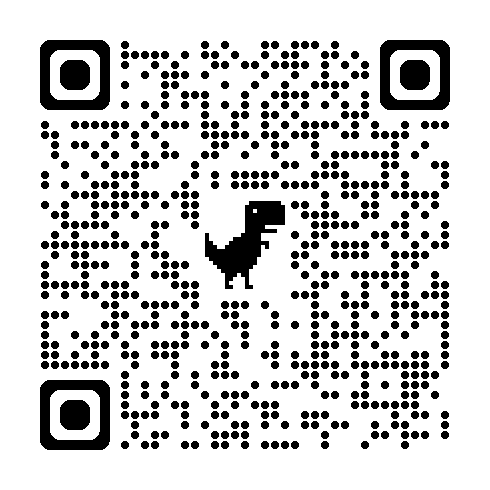

In [1]:
# @title 📋 Feuille de présence (remplir maintenant)
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">📋 Feuille de présence</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/assets/qr_td08_presence.png", width=250))
display(HTML('<a href="https://forms.gle/X4S6x2ickHHd5Q9J9" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le formulaire</button></a>'))

In [2]:
# @title Configuration des ressources (ne pas modifier)
from IPython.display import Image, display, HTML

BASE_URL = "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td08_pandas_agregation_et_transformation/images/"

def afficher_infographie(nom_fichier, largeur=1300):
    display(Image(url=BASE_URL + nom_fichier, width=largeur))

In [3]:
# @title Infographie — Workflow Complet du TD
afficher_infographie("13_workflow_complet_td_pro.png")

# **1. Transformer des DataFrames**

Maîtrisons les bases de pandas. Apprenez à inspecter des DataFrames et à réaliser des manipulations essentielles : trier des lignes, faire des sous-ensembles et ajouter de nouvelles colonnes.

## **1.1 Présentation des Dataframes**

In [ ]:
# @title Infographie — Les opérateurs de comparaison
afficher_infographie("01_operateurs_comparaison_pro.png")

---
---
### **Exercice**

**Égalité**

Pour vérifier l'égalité entre deux valeurs, utilisez `==`. Pour l'inégalité, utilisez `!=`.

```python
2 == (1 + 1)          # True
"intermediate" != "python"  # True
True != False          # True
```

Pour afficher le résultat dans un script, encapsulez la comparaison dans print().

---
### **Instructions**

1. Vérifiez si True est égal à False.
2. Vérifiez si -5 * 15 n'est pas égal à 75.
3. Vérifiez si "pyscript" et "PyScript" sont égaux.
4. Vérifiez si True et 1 sont égaux.

In [ ]:
# Comparison of booleans
print(True == False)

# Comparison of integers
print(-5 * 15 != 75)

# Comparison of strings
print("pyscript" == "PyScript")

# Compare a boolean with an integer
print(True == 1)

False
True
False
True


---
---
### **Exercice**

**Supérieur et inférieur à**

En Python, `<` et `>` comparent deux valeurs. On peut les combiner avec `=` :

```python
3 < 4           # True
3 <= 4          # True
"alpha" <= "beta"  # True  (ordre alphabétique)
```

⚠️ <= est valide — =< ne l'est pas.

---
### **Instructions**

Vérifiez si :
1. x est supérieur ou égal à -10.
2. "test" est inférieur ou égal à y.
3. True est supérieur à False.

In [ ]:
# Comparison of integers
x = -3 * 6
print(x >= -10)


# Comparison of strings
y = "test"
print("test" <= y)


# Comparison of booleans
print(True > False)

False
True
True


---
---
### **Exercice**

**Comparez les tableaux**

Les opérateurs de comparaison fonctionnent aussi avec les tableaux NumPy. La comparaison s'effectue **élément par élément** et renvoie un tableau de booléens.

```python
import numpy as np
arr = np.array([10, 20, 30])
arr >= 15   # → [False, True, True]
```

Deux tableaux NumPy my_house et your_house contiennent les surfaces (en m²) de quatre pièces dans le même ordre : cuisine, salon, chambre, salle de bain.

---
### **Instructions**

1. Affichez un tableau booléen indiquant quelles zones de my_house sont supérieures ou égales à 18.
2. Affichez un tableau booléen indiquant quelles zones de my_house sont plus petites que celles de your_house.

In [ ]:
# Create arrays
import numpy as np
my_house = np.array([18.0, 20.0, 10.75, 9.50])
your_house = np.array([14.0, 24.0, 14.25, 9.0])

# my_house greater than or equal to 18
print(my_house >= 18)

# my_house less than your_house
print(my_house < your_house)

[ True  True False False]
[False  True  True False]


## **1.2 Opérateurs booléens**

In [ ]:
# @title Infographie — Les opérateurs booléens
afficher_infographie("02_operateurs_booleens_pro.png")

---
---
### **Exercice**

**and, or, not (1)**

Les opérateurs booléens permettent de combiner plusieurs comparaisons en une seule expression :

```python
x > 5 and x < 15   # True si x est entre 5 et 15
x < 0 or x > 10    # True si x est hors de [0, 10]
```

---
### **Instructions**

Vérifiez si :
1. my_kitchen est supérieur à 10 et inférieur à 18.
2. my_kitchen est inférieur à 14 ou supérieur à 17.
3. Le double de my_kitchen est plus petit que le triple de your_kitchen.

In [ ]:
# Define variables
my_kitchen = 18.0
your_kitchen = 14.0

# my_kitchen bigger than 10 and smaller than 18?
print(my_kitchen > 10 and my_kitchen < 18)

# my_kitchen smaller than 14 or bigger than 17?
print(my_kitchen < 14 or my_kitchen > 17)

# Double my_kitchen smaller than triple your_kitchen?
print(my_kitchen * 2 < your_kitchen * 3)

False
True
True


---
---
### **Exercice**

**and, or, not (2)**

Analysez ce code Python :

```python
x = 8
y = 9
not(not(x < 3) and not(y > 14 or y > 10))
```
💡 not a une priorité plus élevée que and et or — il est évalué en premier.

Quel sera le résultat ?

1 — True

2 — False

3 — L'exécution entraînera une erreur

---
Entrez le numéro de votre réponse ci-dessous.

In [ ]:
# @title 🔧 Exercice — and, or, not (2)
# ================================================================
#  EXERCICE — Analyser une expression booléenne             [ 1 étape ]
# ================================================================
#
#   1 — True
#   2 — False
#   3 — L'exécution entraînera une erreur
#
# ----------------------------------------------------------------
# Entrez le numéro de votre réponse (1, 2 ou 3)
# ----------------------------------------------------------------
reponse = 2

In [ ]:
# @title ✅ Exécuter la cellule pour vérifier votre réponse
EXPLICATIONS = {
    1: "Incorrect. Déroulez l'expression : not(x < 3) → True, not(y > 14 or y > 10) → True, True and True → True, not(True) → False.",
    2: "Correct ! not(x < 3) vaut True, not(y > 14 or y > 10) vaut True, True and True vaut True, et not(True) donne False.",
    3: "Incorrect. Il n'y a pas d'erreur — les types sont compatibles et la syntaxe est valide.",
}
try:
    r = int(reponse)
    if r == 2:
        print(f"✅ Bonne réponse ({r}) : {EXPLICATIONS[r]}")
    elif r in EXPLICATIONS:
        print(f"❌ Réponse {r} incorrecte : {EXPLICATIONS[r]}")
    else:
        print(f"❌ Réponse non reconnue — attendu 1, 2 ou 3")
except NameError:
    print("❌ reponse n'est pas défini — attribuez un nombre à la variable reponse")
except (ValueError, TypeError):
    print(f"❌ reponse doit être un nombre (1, 2 ou 3) — valeur reçue : {reponse!r}")

✅ Bonne réponse (2) : Correct ! not(x < 3) vaut True, not(y > 14 or y > 10) vaut True, True and True vaut True, et not(True) donne False.


---
---
### **Exercice**

**Opérateurs booléens avec NumPy**

`and`, `or` et `not` ne fonctionnent pas sur les tableaux NumPy. Il faut utiliser leurs équivalents :

```python
np.logical_and(my_house > 13, your_house < 15)
np.logical_or(arr > 18, arr < 10)
np.logical_not(arr > 15)
```

---
### **Instructions**

1. Affichez un tableau booléen indiquant quelles zones de my_house sont supérieures à 18.5 ou inférieures à 10.
2. Affichez un tableau booléen indiquant quelles zones sont inférieures à 11 dans my_house et dans your_house.

In [ ]:
# Create arrays
import numpy as np
my_house = np.array([18.0, 20.0, 10.75, 9.50])
your_house = np.array([14.0, 24.0, 14.25, 9.0])

# my_house greater than 18.5 or smaller than 10
print(np.logical_or(my_house > 18.5, my_house < 10))

# Both my_house and your_house smaller than 11
print(np.logical_and(my_house < 11, your_house < 11))

[False  True False  True]
[False False False  True]


## **1.3 If, elif, else**

In [ ]:
# @title Infographie — If, elif, else
afficher_infographie("03_if_elif_else_pro.png")

---
---
### **Exercice**

**Échauffement**

Analysez ce code :

```python
area = 10.0
if(area < 9) :
    print("small")
elif(area < 12) :
    print("medium")
else :
    print("large")
```
Quel sera le résultat ?

1 — small

2 — medium

3 — large

4 — La syntaxe est incorrecte ; ce code produira une erreur

---
Entrez le numéro de votre réponse ci-dessous.

In [ ]:
# @title 🔧 Exercice — Échauffement
# ================================================================
#  EXERCICE — Analyser un if / elif / else                  [ 1 étape ]
# ================================================================
#
#   1 — small
#   2 — medium
#   3 — large
#   4 — La syntaxe est incorrecte ; ce code produira une erreur
#
# ----------------------------------------------------------------
# Entrez le numéro de votre réponse (1, 2, 3 ou 4)
# ----------------------------------------------------------------
reponse = 2

In [ ]:
# @title ✅ Exécuter la cellule pour vérifier votre réponse
EXPLICATIONS = {
    1: "Incorrect. area = 10.0, donc area < 9 est False — le bloc 'small' ne s'exécute pas.",
    2: "Correct ! area < 9 est False, area < 12 est True → Python affiche 'medium'.",
    3: "Incorrect. area < 12 est True, donc Python affiche 'medium' et ne reach jamais le else.",
    4: "Incorrect. Les parenthèses autour de la condition et l'espace avant le ':' sont valides en Python.",
}
try:
    r = int(reponse)
    if r == 2:
        print(f"✅ Bonne réponse ({r}) : {EXPLICATIONS[r]}")
    elif r in EXPLICATIONS:
        print(f"❌ Réponse {r} incorrecte : {EXPLICATIONS[r]}")
    else:
        print(f"❌ Réponse non reconnue — attendu 1, 2, 3 ou 4")
except NameError:
    print("❌ reponse n'est pas défini — attribuez un nombre à la variable reponse")
except (ValueError, TypeError):
    print(f"❌ reponse doit être un nombre (1, 2, 3 ou 4) — valeur reçue : {reponse!r}")

✅ Bonne réponse (2) : Correct ! area < 9 est False, area < 12 est True → Python affiche 'medium'.


---
---
### **Exercice**

**if**

Deux variables décrivent une pièce de la maison : `room` (nom de la pièce) et `area` (surface en m²).

```python
if room == "kit" :
    print("looking around in the kitchen.")
```
---
### **Instructions**

1. Examinez l'instruction if déjà écrite qui affiche "looking around in the kitchen." si room est égal à "kit".
2. Écrivez une autre instruction if qui affiche "big place!" si area est supérieur à 15.

In [ ]:
# Define variables
room = "kit"
area = 14.0

# if statement for room
if room == "kit" :
    print("looking around in the kitchen.")

# if statement for area
if area > 15 :
    print("big place!")

looking around in the kitchen.


---
---
### **Exercice**

**if, else**

Un `else` permet de gérer le cas où la condition du `if` est `False` :

```python
if room == "kit" :
    print("looking around in the kitchen.")
else :
    print("looking around elsewhere.")
```
---
### **Instructions**

Ajoutez un else à la structure if portant sur area, afin d'afficher "pretty small." si area > 15 est False.

In [ ]:
# Define variables
room = "kit"
area = 14.0

# if-else construct for room
if room == "kit" :
    print("looking around in the kitchen.")
else :
    print("looking around elsewhere.")

# if-else construct for area
if area > 15 :
    print("big place!")
else:
    print("pretty small.")

looking around in the kitchen.
pretty small.


---
---
### **Exercice**

**if, elif, else**

`elif` permet d'ajouter des conditions intermédiaires entre `if` et `else` :

```python
if room == "kit" :
    print("looking around in the kitchen.")
elif room == "bed" :
    print("looking around in the bedroom.")
else :
    print("looking around elsewhere.")
```

---
### **Instructions**

Ajoutez un elif à la structure if portant sur area pour afficher "medium size, nice!" si area est supérieur à 10.

In [ ]:
# Define variables
room = "bed"
area = 14.0

# if-elif-else construct for room
if room == "kit" :
    print("looking around in the kitchen.")
elif room == "bed":
    print("looking around in the bedroom.")
else :
    print("looking around elsewhere.")

# if-elif-else construct for area
if area > 15 :
    print("big place!")
elif area > 10:
    print("medium size, nice!")
else :
    print("pretty small.")

looking around in the bedroom.
medium size, nice!


## **1.4 Filtrer des Dataframes Pandas**

In [ ]:
# @title Infographie — Filtrer des Dataframes Pandas
afficher_infographie("04_filtrer_dataframes_pro.png")

---
---
### **Exercice**

Vous travaillez avec le jeu de données **cars**, qui contient pour chaque pays :
- `cars_per_cap` : nombre de voitures pour 1 000 habitants
- `country` : nom du pays
- `drives_right` : `True` si le pays conduit à droite, `False` sinon

L'objectif est de **filtrer** le DataFrame pour ne garder que les pays où l'on conduit à droite.

**Rappel — les 3 étapes du filtrage :**
1. Extraire la colonne cible → **Series**
2. Utiliser la Series booléenne comme masque
3. Appliquer le masque au DataFrame

---
### **Instructions**
1. Extrayez la colonne `drives_right` sous forme de Series et stockez-la dans `dr`.
2. Utilisez `dr` pour filtrer `cars` et stockez le résultat dans `sel`.
3. Affichez `sel`.

In [ ]:
import pandas as pd
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/datasets/cars.csv",
    "cars.csv"
)
cars = pd.read_csv("cars.csv", index_col=0)

# Extract drives_right column as Series: dr
dr = cars['drives_right']

# Use dr to subset cars: sel
sel = cars[dr]

# Print sel
print(sel)

     cars_per_cap        country  drives_right
US            809  United States          True
RU            200         Russia          True
MOR            70        Morocco          True
EG             45          Egypt          True


---
---
### **Exercice**

Dans l'exercice précédent, vous avez utilisé une variable intermédiaire `dr` pour stocker le masque booléen avant de filtrer `cars`.

Il est possible de **tout écrire en une seule ligne** en plaçant la condition directement entre les crochets.

---
### **Instructions**
Réécrivez le filtrage en une seule ligne, sans variable intermédiaire, et stockez le résultat dans `sel`.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Convert code to a one-liner
sel = cars[cars['drives_right']]

# Print sel
print(sel)

     cars_per_cap        country  drives_right
US            809  United States          True
RU            200         Russia          True
MOR            70        Morocco          True
EG             45          Egypt          True


---
---
### **Exercice**

Vous souhaitez identifier les pays où **de nombreuses personnes possèdent une voiture** — c'est-à-dire ceux dont le nombre de voitures pour 1 000 habitants (`cars_per_cap`) dépasse **500**.

---
### **Instructions**
1. Extrayez la colonne `cars_per_cap` sous forme de Series et stockez-la dans `cpc`.
2. Comparez `cpc` à `500` avec l'opérateur `>` et stockez le masque booléen dans `many_cars`.
3. Filtrez `cars` avec `many_cars` et stockez le résultat dans `car_maniac`.
4. Affichez `car_maniac`.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Create car_maniac: observations that have a cars_per_cap over 500
cpc = cars['cars_per_cap']
many_cars = cpc > 500
car_maniac = cars[many_cars]

# Print car_maniac
print(car_maniac)

     cars_per_cap        country  drives_right
US            809  United States          True
AUS           731      Australia         False
JPN           588          Japan         False


---
---
### **Exercice**

Pour filtrer sur **deux conditions simultanées**, `and` ne fonctionne pas sur les Series pandas.
Il faut utiliser `np.logical_and()` à la place.

**Exemple fourni** — pays avec `cars_per_cap` entre 10 et 80 :
```python
cpc = cars['cars_per_cap']
between = np.logical_and(cpc > 10, cpc < 80)
medium = cars[between]
```
---
### **Instructions**
Adaptez cet exemple pour créer medium : les pays dont cars_per_cap est strictement entre 100 et 500.
Affichez medium.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Import numpy, you'll need this
import numpy as np

# Create medium: observations with cars_per_cap between 100 and 500
medium = cars[np.logical_and(cars['cars_per_cap'] >= 100, cars['cars_per_cap'] <= 500)]

# Print medium
print(medium)

    cars_per_cap country  drives_right
RU           200  Russia          True


# **2. Boucles**   

Vous pouvez utiliser plusieurs techniques pour exécuter le code Python de manière répétée. Alors que les boucles sont comme des instructions « if » répétées, la boucle « for » itère sur toutes sortes de structures de données. Découvrez-les dans ce chapitre.

## **2.1 Boucle "while"**

In [ ]:
# @title Infographie — Boucle "while"
afficher_infographie("05_boucle_while_pro.png")

---
---
### **Exercice**

La boucle `while` est une instruction `if` répétée : le code s'exécute encore et encore **tant que la condition est `True`**.

Combien de fois la boucle suivante affiche-t-elle quelque chose ?

```python
x = 1
while x < 4:
    print(x)
    x = x + 1
```

Choisissez la bonne réponse :

- 0
- 1
- 2
- 3
- 4

In [ ]:
# Entrez le numéro de la bonne réponse (0, 1, 2, 3 ou 4)
reponse = 3

In [ ]:
# @title ✅ Exécuter la cellule pour vérifier votre réponse
EXPLICATIONS = {
    0: "Incorrect. x vaut 1 au départ, et 1 < 4 est True : la boucle s'exécute bien.",
    1: "Incorrect. La boucle tourne jusqu'à ce que x atteigne 4, pas seulement une fois.",
    2: "Incorrect. La boucle affiche x=1, x=2 et x=3 — comptez à nouveau.",
    3: "Correct ! x prend les valeurs 1, 2 puis 3 (3 affichages). Quand x=4, la condition 4 < 4 est False : la boucle s'arrête.",
    4: "Incorrect. Quand x=4, la condition x < 4 est False : la boucle s'arrête sans afficher 4.",
}

try:
    r = int(reponse)
    if r == 3:
        print(f"✅ Bonne réponse ({r}) : {EXPLICATIONS[r]}")
    elif r in EXPLICATIONS:
        print(f"❌ Réponse {r} incorrecte : {EXPLICATIONS[r]}")
    else:
        print(f"❌ Réponse non reconnue : {reponse!r} — attendu un nombre entre 1 et 5")
except NameError:
    print("❌ reponse n'est pas défini — attribuez un nombre à la variable reponse")
except (ValueError, TypeError):
    print(f"❌ reponse doit être un nombre (1 à 5) — valeur reçue : {reponse!r}")

✅ Bonne réponse (3) : Correct ! x prend les valeurs 1, 2 puis 3 (3 affichages). Quand x=4, la condition 4 < 4 est False : la boucle s'arrête.


---
---
### **Exercice**

Vous allez coder une boucle `while` pour simuler un **système de correction de pendule inversé** : tant qu'il y a un décalage par rapport à la position droite, la boucle corrige progressivement ce décalage.

---
### **Instructions**
1. Créez la variable `offset` avec la valeur initiale `8`.
2. Écrivez une boucle `while` qui tourne tant que `offset` n'est pas égal à `0`.
   À l'intérieur de la boucle :
   - Affichez `"correcting..."`.
   - Diminuez `offset` de `1`.
   - Affichez la nouvelle valeur de `offset`.

In [ ]:
# Initialize offset
offset = 8

# Code the while loop
while offset > 0:
  print("correcting...")
  offset = offset - 1
  print(offset)

correcting...
7
correcting...
6
correcting...
5
correcting...
4
correcting...
3
correcting...
2
correcting...
1
correcting...
0


---
---
### **Exercice**

Si `offset` est **négatif**, la boucle précédente tourne à l'infini : `offset` diminue sans jamais atteindre `0`.

La solution : ajouter un `if-else` à l'intérieur de la boucle pour corriger dans le **bon sens** selon le signe d'`offset`.

---
### **Instructions**
1. Initialisez `offset` à `-6`.
2. Complétez le `if-else` à l'intérieur de la boucle :
   - Si `offset > 0` → diminuez `offset` de `1`.
   - Sinon → augmentez `offset` de `1`.

In [ ]:
# Initialize offset
offset = -6

# Code the while loop
while offset != 0 :
    print("correcting...")
    if offset > 0 :
      offset = offset - 1
    else :
      offset = offset + 1
    print(offset)

correcting...
-5
correcting...
-4
correcting...
-3
correcting...
-2
correcting...
-1
correcting...
0


## **2.2 Boucle "for"**

In [ ]:
# @title Infographie — Boucle "for"
afficher_infographie("06_boucle_for_pro.png")

---
---
### **Exercice**

La boucle `for` parcourt automatiquement chaque élément d'une liste, l'un après l'autre.

```python
fam = [1.73, 1.68, 1.71, 1.89]
for height in fam:
    print(height)
```
---
### **Instructions**
Écrivez une boucle for qui parcourt tous les éléments de areas et affiche chaque élément séparément.

In [ ]:
# areas list
areas = [11.25, 18.0, 20.0, 10.75, 9.50]

# Code the for loop
for area in areas:
  print(area)

11.25
18.0
20.0
10.75
9.5


---
---
### **Exercice**

`enumerate()` permet d'accéder simultanément à **l'indice** et à la **valeur** de chaque élément :

```python
fam = [1.73, 1.68, 1.71, 1.89]
for index, height in enumerate(fam):
    print("person " + str(index) + ": " + str(height))
```
---
### **Instructions**
Adaptez la boucle for sur areas pour utiliser enumerate() et afficher une ligne de la forme :
room 0: 11.25
room 1: 18.0
… et ainsi de suite.

In [ ]:
# areas list
areas = [11.25, 18.0, 20.0, 10.75, 9.50]

# Change for loop to use enumerate() and update print()
for index, value in enumerate(areas):
    print("room", index, ":", value)

room 0 : 11.25
room 1 : 18.0
room 2 : 20.0
room 3 : 10.75
room 4 : 9.5


---
---
### **Exercice**

Les indices Python commencent à `0`, mais pour un affichage lisible, il est parfois préférable de commencer à `1`.

---
### **Instructions**
Modifiez le `print()` pour que l'affichage commence à `room 1` au lieu de `room 0` :
`room 1: 11.25`
`room 2: 18.0`
… et ainsi de suite.

In [ ]:
# areas list
areas = [11.25, 18.0, 20.0, 10.75, 9.50]

# Code the for loop
for index, area in enumerate(areas) :
    print("room " + str(index+1) + ": " + str(area))

room 1: 11.25
room 2: 18.0
room 3: 20.0
room 4: 10.75
room 5: 9.5


---
---
### **Exercice**

La variable `house` est une liste de listes : chaque sous-liste contient le nom d'une pièce et sa superficie.

```python
house = [["hallway", 11.25],
         ["kitchen", 18.0],
         ["living room", 20.0],
         ["bedroom", 10.75],
         ["bathroom", 9.50]]
```

Lorsqu'on itère sur une liste de listes, chaque élément room est lui-même une liste de deux valeurs que l'on peut déballer en deux variables : for x, y in house.

---
### **Instructions**

Écrivez une boucle for qui parcourt chaque sous-liste de house et affiche :
the hallway is 11.25 sqm
the kitchen is 18.0 sqm
… et ainsi de suite.

In [ ]:
# house list of lists
house = [["hallway", 11.25],
         ["kitchen", 18.0],
         ["living room", 20.0],
         ["bedroom", 10.75],
         ["bathroom", 9.50]]

# Build a for loop from scratch
for liste in house:
  print(f"the {liste[0]} is {liste[1]} sqm")


the hallway is 11.25 sqm
the kitchen is 18.0 sqm
the living room is 20.0 sqm
the bedroom is 10.75 sqm
the bathroom is 9.5 sqm


## **2.3 Structure de données en boucle - Partie 1**

In [ ]:
# @title Infographie — Structure de données en boucle - Partie 1
afficher_infographie("07_boucles_structures_donnees_pro.png")

---
---
### **Exercice**

Pour parcourir un dictionnaire et accéder simultanément aux clés et aux valeurs, on utilise la méthode `.items()` :

```python
for key, value in world.items():
    print(key + " -- " + str(value))
```

Le dictionnaire europe contient des pays européens comme clés et leurs capitales comme valeurs.

---
### **Instructions**

Écrivez une boucle for qui parcourt chaque paire clé/valeur de europe et affiche :
the capital of france is paris
the capital of germany is berlin
… et ainsi de suite.

In [ ]:
# Definition of dictionary
europe = {'spain':'madrid', 'france':'paris', 'germany':'berlin',
          'norway':'oslo', 'italy':'rome', 'poland':'warsaw', 'austria':'vienna' }

# Iterate over europe
for k, v in europe.items():
  print("the capital of", k, "is", v)

the capital of spain is madrid
the capital of france is paris
the capital of germany is berlin
the capital of norway is oslo
the capital of italy is rome
the capital of poland is warsaw
the capital of austria is vienna


---
---
### **Exercice**

Pour un tableau NumPy **1D**, la boucle `for` classique suffit. Pour un tableau **2D**, il faut `np.nditer()` pour accéder à chaque élément individuellement — sans ça, la boucle itère sur les lignes entières.

```python
for x in my_array:          # 1D — élément par élément
    ...

for x in np.nditer(my_array):   # 2D — élément par élément
    ...
```

---
### **Instructions**

1. Importez numpy sous l'alias np.
2. Écrivez une boucle for sur np_height qui affiche "x inches" pour chaque valeur.
3. Écrivez une boucle for sur np_baseball avec np.nditer() qui affiche chaque élément.

In [ ]:
# Import numpy as np
import numpy as np

np_height = np.array([74, 74, 72, 72, 73, 69, 69, 71, 76, 71])

np_baseball = np.array([[74, 180],
                        [74, 215],
                        [72, 210],
                        [72, 188],
                        [73, 176],
                        [69, 209],
                        [69, 200],
                        [71, 231],
                        [76, 180],
                        [71, 188]])
# For loop over np_height
for height in np_height:
  print(height, "inches")

# For loop over np_baseball
for baseball in np.nditer(np_baseball):
  print(baseball)

74 inches
74 inches
72 inches
72 inches
73 inches
69 inches
69 inches
71 inches
76 inches
71 inches
74
180
74
215
72
210
72
188
73
176
69
209
69
200
71
231
76
180
71
188


## **2.4 Structure de données en boucle - Partie 2**

In [ ]:
# @title Infographie — Structure de données en boucle - Partie 2
afficher_infographie("08_boucles_dataframes_pro.png")

---
---
### **Exercice**

Pour itérer sur les lignes d'un DataFrame Pandas, on utilise `.iterrows()`. À chaque tour de boucle, deux éléments sont disponibles : le libellé de la ligne et son contenu sous forme de Series.

```python
for lab, row in brics.iterrows():
    ...
```
Le DataFrame cars contient des informations sur sept pays : nombre de voitures par habitant (cars_per_cap), nom du pays (country) et sens de conduite (drives_right).

---
### **Instructions**

Écrivez une boucle for qui parcourt les lignes de cars et, à chaque itération, affiche :
1. Le libellé de la ligne (ex. US, AUS…)
2. Le contenu complet de la ligne

In [ ]:
# Import cars data
import pandas as pd
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/datasets/cars.csv",
    "cars.csv"
)
cars = pd.read_csv('cars.csv', index_col = 0)

# Iterate over rows of cars
for lab, row in cars.iterrows():
  print(lab)
  print(row)

US
cars_per_cap              809
country         United States
drives_right             True
Name: US, dtype: object
AUS
cars_per_cap          731
country         Australia
drives_right        False
Name: AUS, dtype: object
JPN
cars_per_cap      588
country         Japan
drives_right    False
Name: JPN, dtype: object
IN
cars_per_cap       18
country         India
drives_right    False
Name: IN, dtype: object
RU
cars_per_cap       200
country         Russia
drives_right      True
Name: RU, dtype: object
MOR
cars_per_cap         70
country         Morocco
drives_right       True
Name: MOR, dtype: object
EG
cars_per_cap       45
country         Egypt
drives_right     True
Name: EG, dtype: object


---
---
### **Exercice**

Les données de ligne générées par `iterrows()` sont des Series Pandas. On peut en extraire une valeur par son nom de colonne :

```python
for lab, row in brics.iterrows():
    print(row['country'])
```
---
### **Instructions**

Adaptez la boucle for pour afficher à chaque itération une ligne de la forme "US: 809" — c'est-à-dire le libellé de ligne suivi de cars_per_cap.

Le résultat attendu :

US: 809

AUS: 731

JPN: 588

IN: 18

RU: 200

MOR: 70

EG: 45

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Adapt for loop
for lab, row in cars.iterrows() :
    print(lab+":", row["cars_per_cap"])

US: 809
AUS: 731
JPN: 588
IN: 18
RU: 200
MOR: 70
EG: 45


---
---
### **Exercice**

Dans une boucle `iterrows()`, on peut écrire dans le DataFrame à l'aide de `loc` pour ajouter une nouvelle colonne calculée ligne par ligne :

```python
for lab, row in brics.iterrows():
    brics.loc[lab, "name_length"] = len(row["country"])
```

---

### **Instructions**

1. Utilisez une boucle for pour ajouter une colonne "COUNTRY" contenant le nom du pays en majuscules (utilisez .upper()).
2. Affichez cars après la boucle (sans indentation) pour vérifier le résultat.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Code for loop that adds COUNTRY column
for lab, row in cars.iterrows():
  cars.loc[lab, "COUNTRY"] = row["country"].upper()

# Print cars
print(cars)

     cars_per_cap        country  drives_right        COUNTRY
US            809  United States          True  UNITED STATES
AUS           731      Australia         False      AUSTRALIA
JPN           588          Japan         False          JAPAN
IN             18          India         False          INDIA
RU            200         Russia          True         RUSSIA
MOR            70        Morocco          True        MOROCCO
EG             45          Egypt          True          EGYPT


---
---
### **Exercice**

La méthode `apply()` est plus efficace qu'une boucle `iterrows()` pour transformer une colonne entière. Elle applique une fonction à chaque valeur sans créer de Series intermédiaire :

```python
# Avec iterrows() — moins efficace
for lab, row in brics.iterrows():
    brics.loc[lab, "name_length"] = len(row["country"])

# Avec apply() — plus efficace
brics["name_length"] = brics["country"].apply(len)
```

Pour appeler une méthode comme .upper() avec apply(), on utilise str.upper (sans parenthèses).

---
### **Instructions**

1. Remplacez la boucle for par une seule ligne utilisant .apply(str.upper) pour créer la colonne "COUNTRY".
2. Affichez cars pour vérifier le résultat.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Use .apply(str.upper)
cars["COUNTRY"] = cars["country"].apply(str.upper)
print(cars)

     cars_per_cap        country  drives_right        COUNTRY
US            809  United States          True  UNITED STATES
AUS           731      Australia         False      AUSTRALIA
JPN           588          Japan         False          JAPAN
IN             18          India         False          INDIA
RU            200         Russia          True         RUSSIA
MOR            70        Morocco          True        MOROCCO
EG             45          Egypt          True          EGYPT


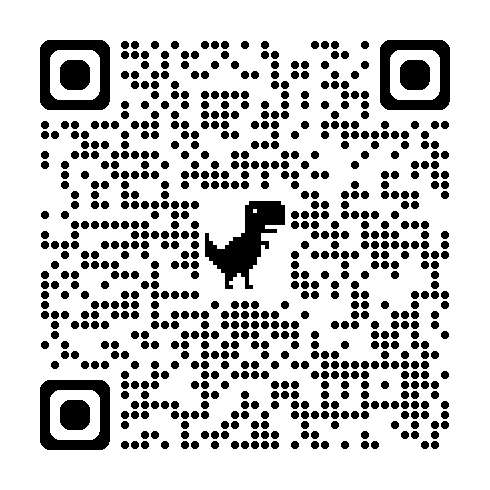

In [ ]:
# @title 🧠 Quiz de fin de séance
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">🧠 Quiz fin de séance</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td06_Logique_flux_de_controle_filtrage_et_boucles/assets/qr_td06_quiz.png", width=250))
display(HTML('<a href="https://forms.gle/quJhqGE9syv3YtYJ9" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le quiz</button></a>'))